# Linear Regression  (선형회귀)
: 머신러닝에서 가장 기본적 지도학습 알고리즘 중 하나로, 입력 변수(X)와 출력 변수 (y) 간의 선형 관계를 찾는 데 사용
1) 목적: 주어진 이력 변수로부터 출력 변수를 예측하기 위한 최적의 직선(회귀선)을 찾는 것

In [15]:
## 선형회귀 모델 실습
### 모델 생성
import pandas as pd
from sklearn.model_selection import train_test_split # 데이터 분리
from sklearn.linear_model import LinearRegression # 선형 회귀 모델
from sklearn.metrics import mean_squared_error, r2_score #평가 지표
import numpy as np

### 1. 데이터로드
path = 'C:/juehyeon/aice_test/materials/datasets/'
data = pd.read_csv(path + 'winequality-white.csv')
data.head()

### 2. 입/출력 분리 
### 독립변수(X) : quality 제외 나머지 특성
### 종속변수(y) : quality
X = data.drop(['quality','alcohol'], axis = 1) 
y = data['quality']

In [6]:
### 3. 학습용(80%) / 테스트용(20%)으로 데이터 나누기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [10]:
### 4. 모델 생성 및 학습
model = LinearRegression() # 선형 회귀 학습 모델 생성
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
### 5. 테스트 데이터로 예측 수행
y_pred = model.predict(X_test)

In [12]:
### 6. 모델 평가 
mse = mean_squared_error(y_test, y_pred) # 평균 제곱 오차
r2 = r2_score(y_test, y_pred) # 결정 계수 계산 

In [13]:
### 7. 결과 출력
print("Mean Squared Error: ", mse)
print("R^2 Score: ", r2)

Mean Squared Error:  0.7137778530412311
R^2 Score:  0.07836977206253493


In [16]:
## 다양한 회귀모델 평가 코드
### 평가 지표 계산
mse = mean_squared_error(y_test, y_pred) # 평균 제곱 오차
rmse = np.sqrt(mse) # 루트 평균 제곱 오차
r2 = r2_score(y_test, y_pred) # 결정 계수

### 평가 결과 출력
print("Mean Squared Error: " , mse)
print("Root Mean Sqaured Error : ", rmse)
print("R^2 Score :", r2)


Mean Squared Error:  0.7137778530412311
Root Mean Sqaured Error :  0.8448537465391457
R^2 Score : 0.07836977206253493


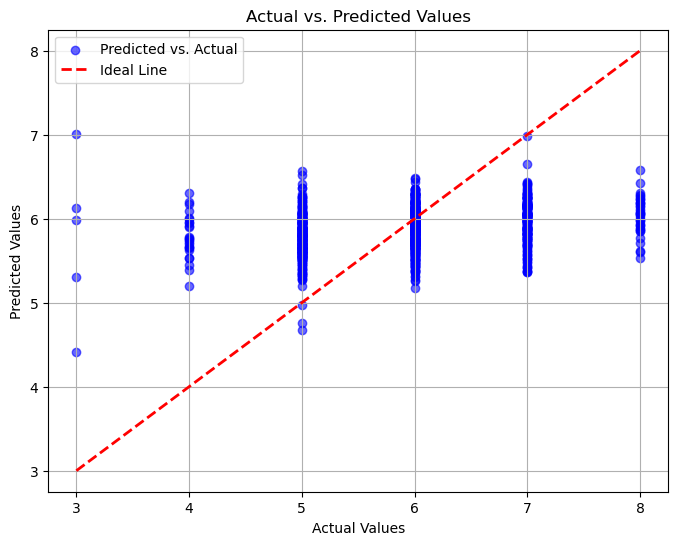

In [19]:
import matplotlib.pyplot as plt

### 실제 vs. 예측값 비교
plt.figure(figsize = (8,6))
plt.scatter(y_test, y_pred, alpha = 0.6, color = 'blue', label = 'Predicted vs. Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw = 2, label = 'Ideal Line')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.legend()
plt.grid()
plt.show()

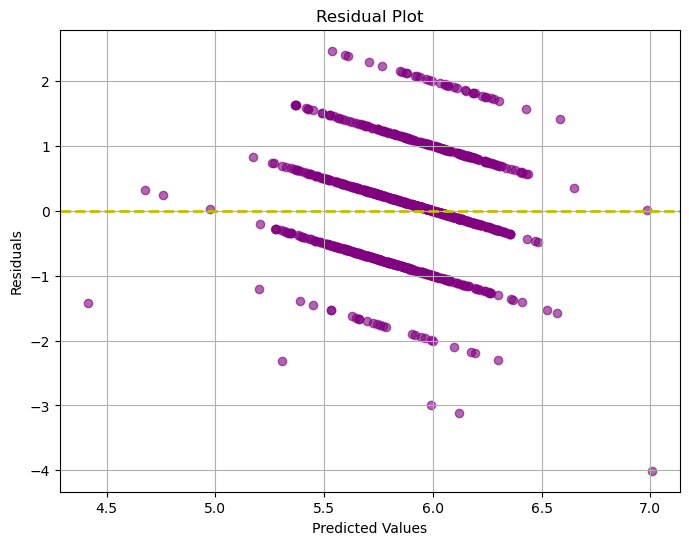

In [21]:
## 잔차 (Residual) 시각화
residuals = y_test - y_pred # 잔차 계산 
plt.figure(figsize = (8,6))
plt.scatter(y_pred, residuals, alpha = 0.6, color = 'purple')
plt.axhline(y = 0, color = 'y', linestyle = '--', lw = 2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid()
plt.show()